<a href="https://colab.research.google.com/github/ElFuegoX/100DaysofML/blob/main/Notebooks/008_Bayesian_Linear_Regression/algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importation des packages

In [27]:

# Importer les modules nécessaires
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Chargement des données

Les données concernent  des informations qui permettent de décider de la qualité d'un vin.

In [28]:
whine_quality = pd.read_csv('WineQT.csv', sep=',')

In [29]:

whine_quality.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Informations sur l'ensemble de données

Cet ensemble de données unifié combine les échantillons de vins rouges et blancs de la variété portugaise "Vinho Verde" (nord du Portugal). Il est issu des deux fichiers originaux du UCI Machine Learning Repository (2009), et de nombreuses versions sur Kaggle l'ont fusionné en un seul fichier en ajoutant une colonne indiquant le type de vin (red / white). L'objectif principal est de modéliser / prédire la qualité du vin à partir de ses propriétés physico-chimiques mesurées en laboratoire.


Variables (features) – 11

- fixed acidity : Acidité fixe (acides non volatils)  en g(tartrique)/dm³

- volatile acidity : Acidité volatile (lié aux acides acétiques, impacte l'arôme) – en g(acétique)/dm³

- citric acid : Acide citrique (ajoute de la fraîcheur et équilibre l'acidité) – en g/dm³

- residual sugar : Sucre résiduel (sucre restant après fermentation) – en g/dm³

- chlorides : Chlorures (sel) – en g(chlorure de sodium)/dm³

- free sulfur dioxide : Dioxyde de soufre libre (conservateur, antioxydant) – en mg/dm³
total sulfur dioxide : Dioxyde de soufre total – en mg/dm³

- density : Densité du vin – en g/cm³ (proche de 1, liée à l'alcool et au sucre)
pH : Niveau de pH (acidité/basicité) – échelle de 0 à 14

- sulphates : Sulfates (dérivés du SO₂, aident à la conservation) – en g(potassium sulphate)/dm³

- alcohol : Teneur en alcool – en % vol.

- quality : Qualité du vin (variable cible)

- Échelle : 3 à 9 (3 = très mauvais, 9 = excellent)


## Exploration des données

In [30]:
whine_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [31]:
whine_quality.describe(include='all')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [32]:
whine_quality.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


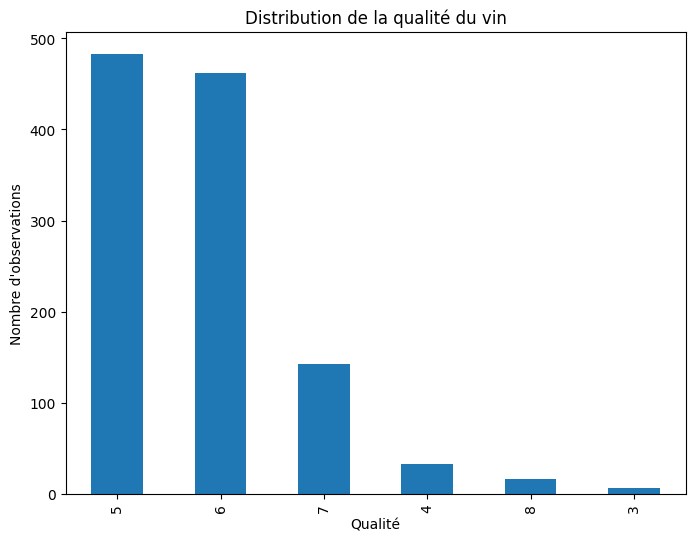

In [33]:
# Distribution de la variable cible 'quality'
plt.figure(figsize=(8, 6))
whine_quality['quality'].value_counts().plot(kind='bar')
plt.title('Distribution de la qualité du vin')
plt.xlabel('Qualité')
plt.ylabel('Nombre d\'observations')
plt.show()

In [34]:
# Créer une nouvelle version de la base de données sans les variables "quality" et "id"
whine_quality_new = whine_quality.drop(columns=['quality', 'Id'], axis=1)
whine_quality_new.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


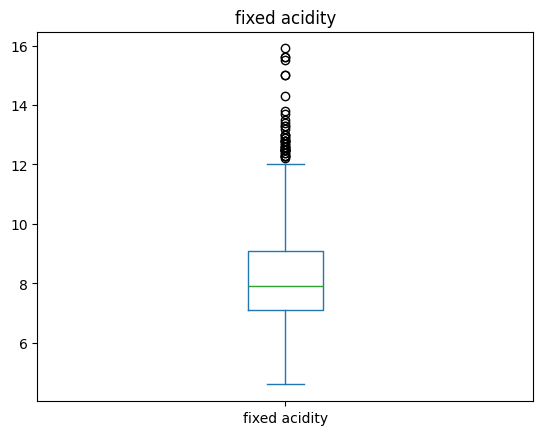

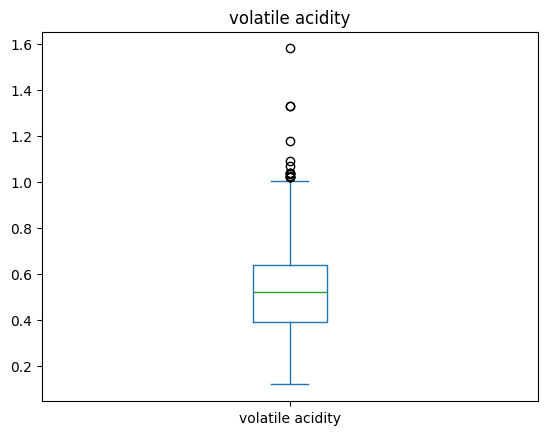

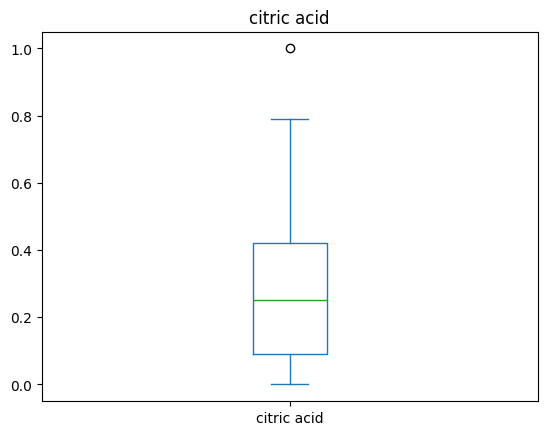

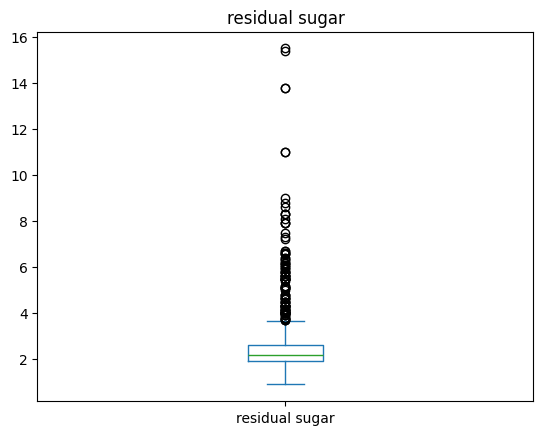

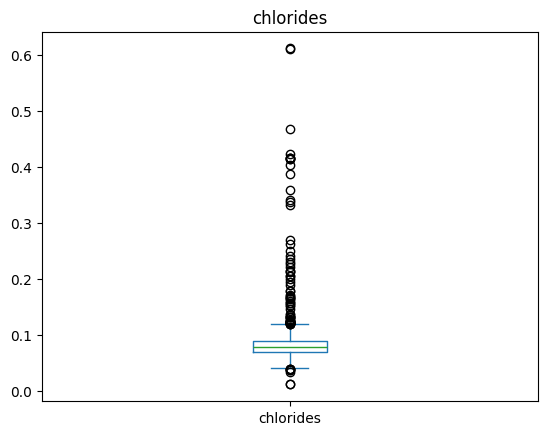

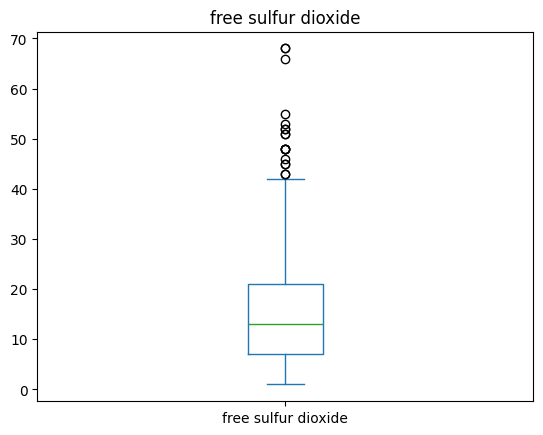

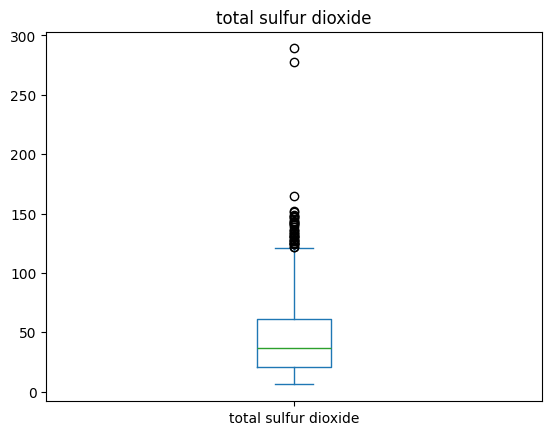

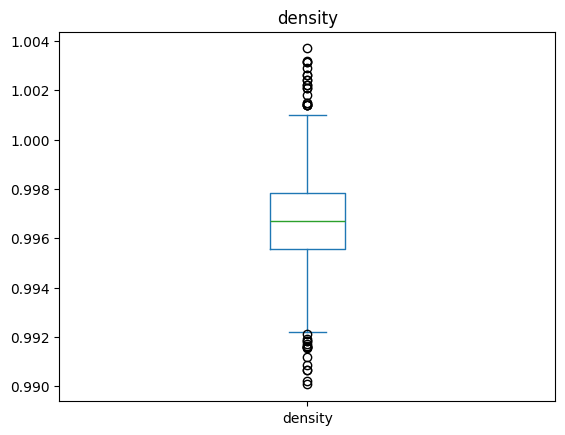

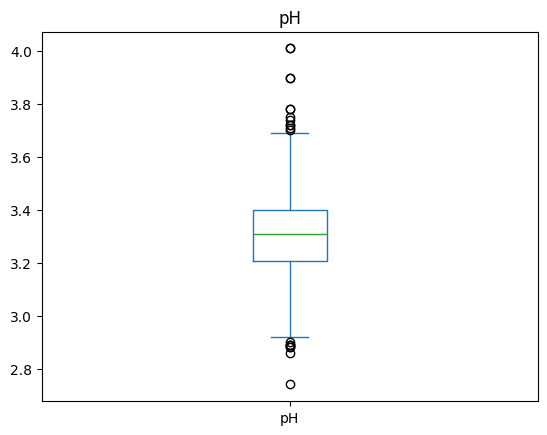

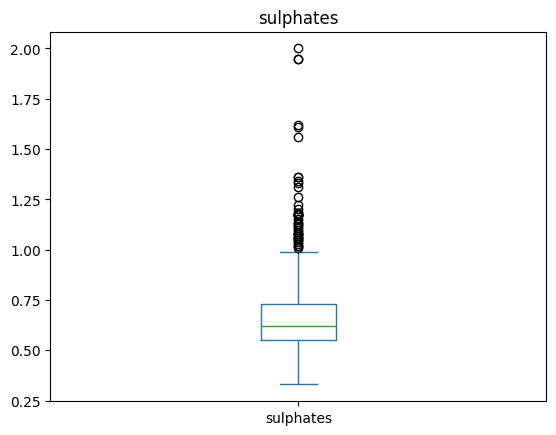

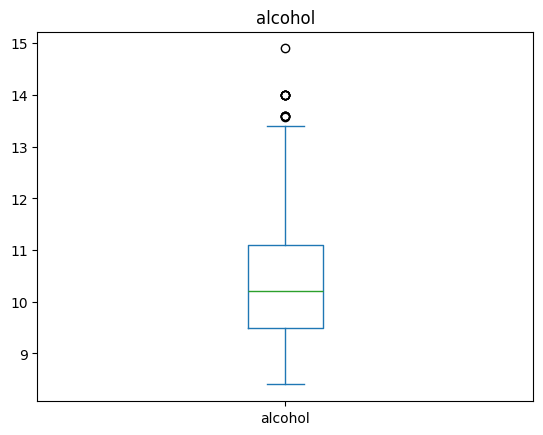

In [35]:
# Générer un box plot pour chaque variable
for var in whine_quality_new.columns:
    whine_quality_new[var].plot(kind='box')
    plt.title(var)
    plt.show()

## Analyse bivariée et création des classes

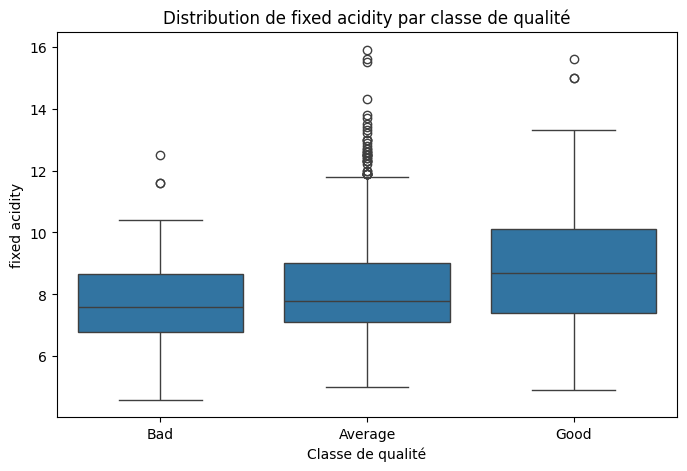

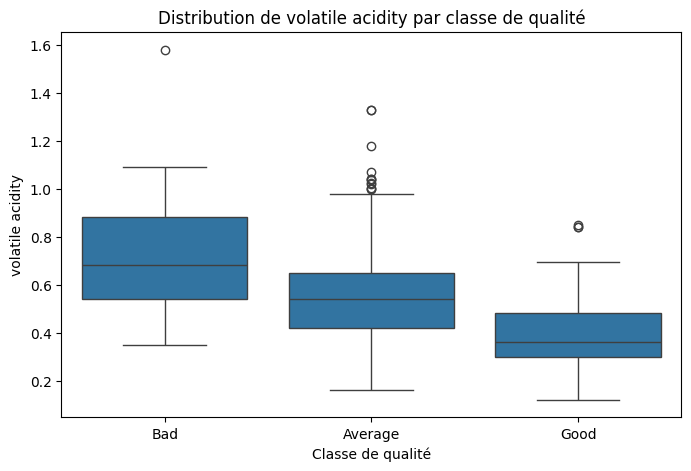

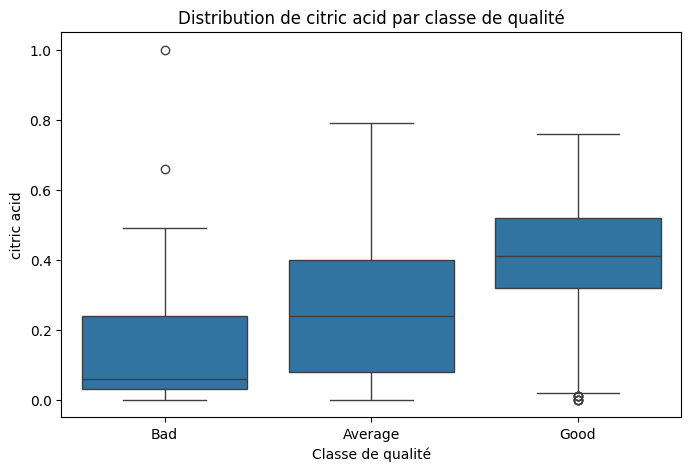

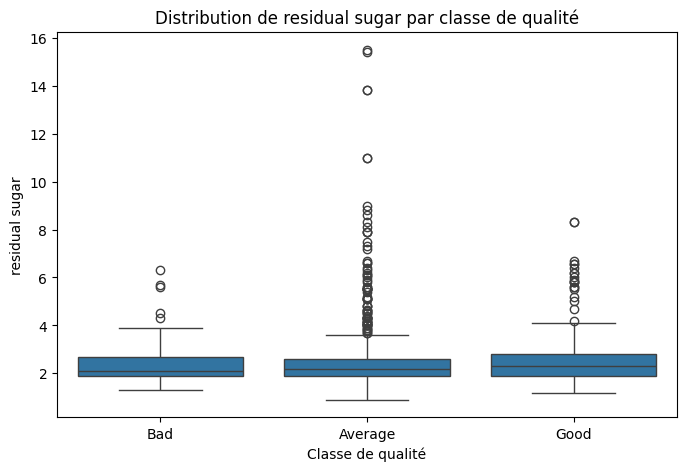

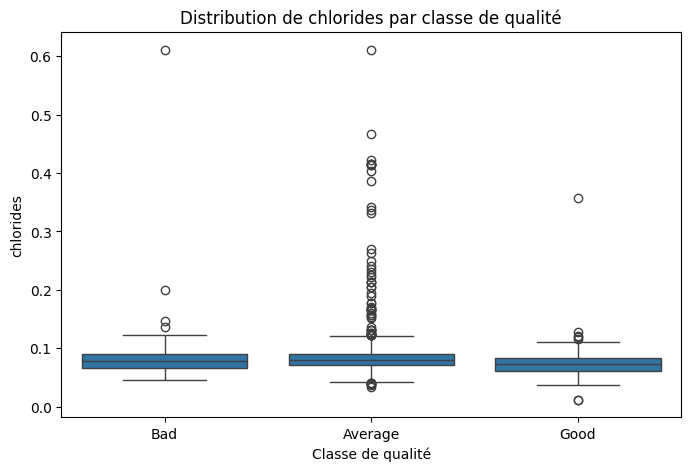

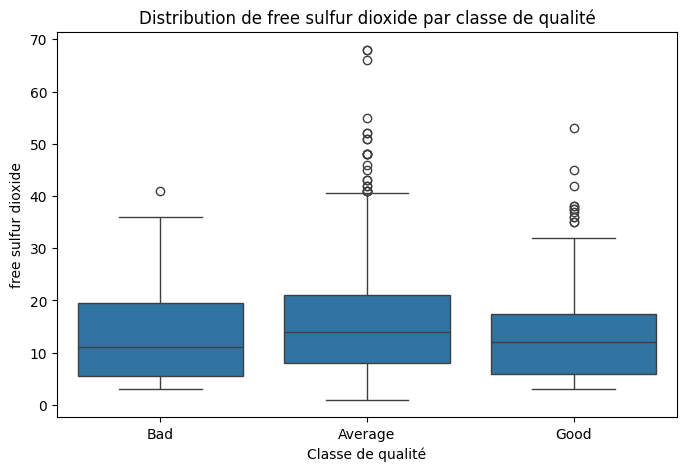

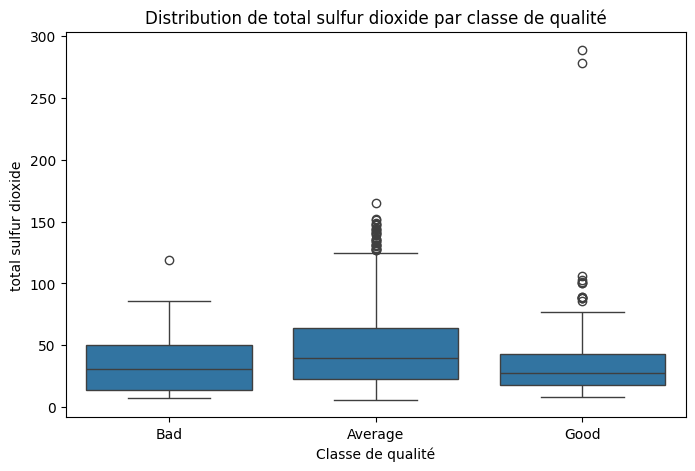

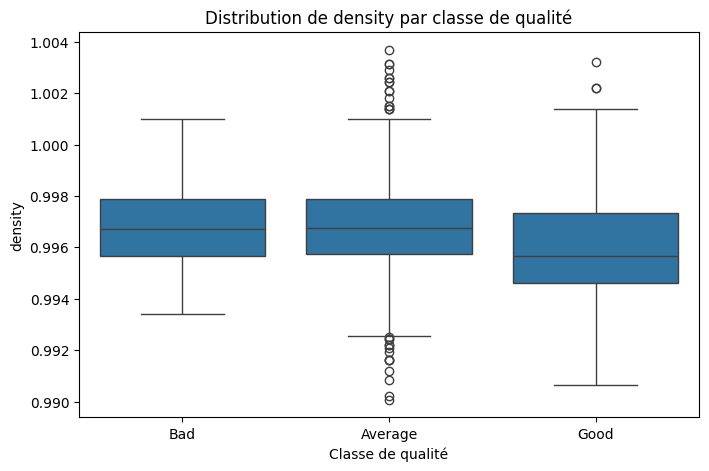

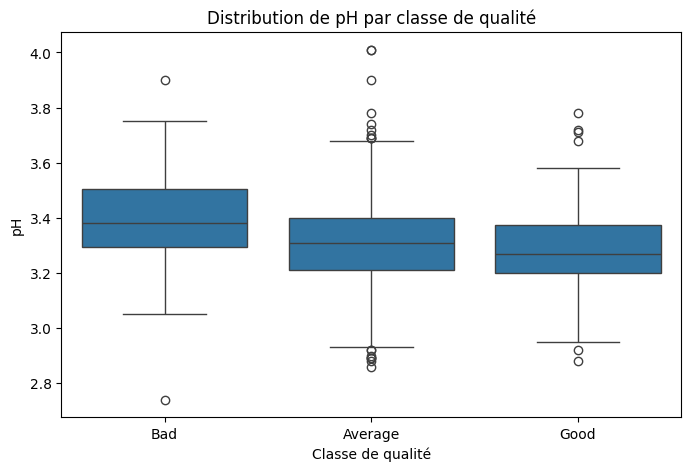

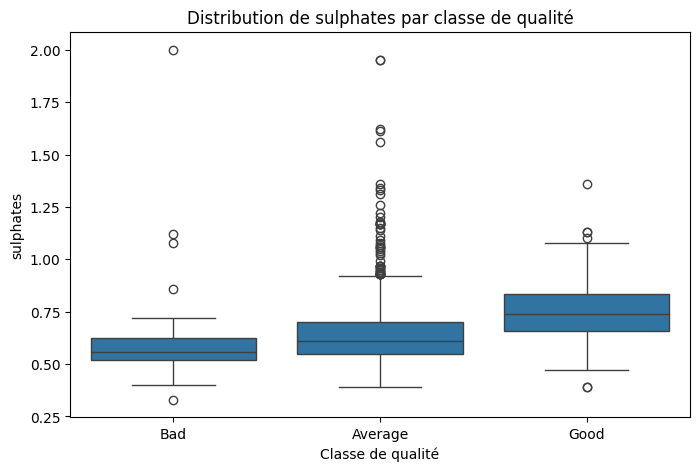

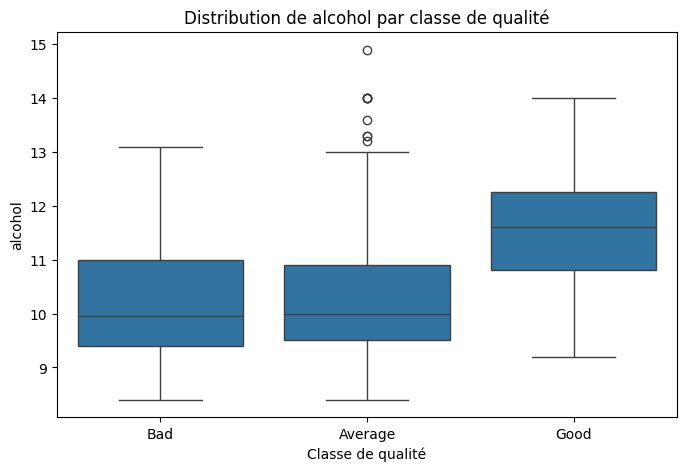

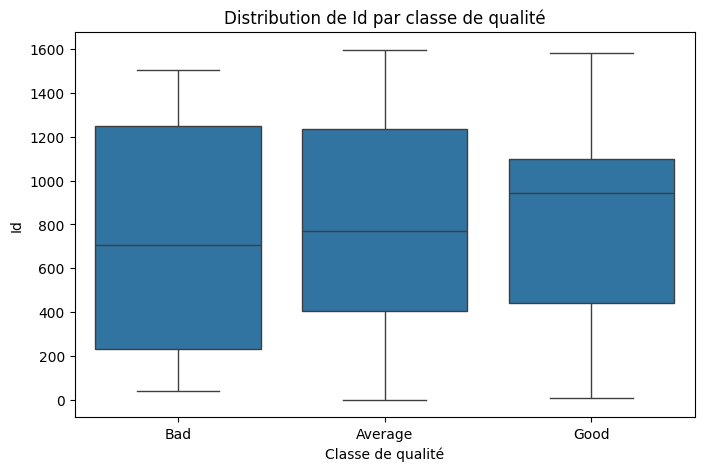

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer trois classes pour la variable quality: Bad (3,4), Average (5,6) et Good (7,8)
whine_quality['quality'] = whine_quality['quality'].apply(
    lambda x: 'Bad' if (x <= 4) else ('Average' if (x <= 6) else 'Good')
)

# Définir l'ordre des catégories pour un affichage logique
quality_order = ['Bad', 'Average', 'Good']

# Générer un box plot pour chaque variable en fonction de la classe de qualité
for var in whine_quality.columns:
    if var != 'quality':
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='quality', y=var, data=whine_quality, order=quality_order)
        plt.title(f'Distribution de {var} par classe de qualité')
        plt.xlabel('Classe de qualité')
        plt.ylabel(var)
        plt.show()

In [37]:
# Créer une colonne supplémentaire pour la classe de qualité ( Bad=0, Average=1, Good=2)
quality_mapping = {'Bad': 0, 'Average': 1, 'Good': 2}
whine_quality_new['quality_class'] = whine_quality['quality'].map(quality_mapping)

whine_quality_new.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


In [38]:
import scipy.stats as stats
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in whine_quality_new.columns:
    # Calculer les groupes de valeurs
    groups = [whine_quality_new[whine_quality_new['quality_class'] == 0][var], whine_quality_new[whine_quality_new['quality_class'] == 1][var], whine_quality_new[whine_quality_new['quality_class'] == 2][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)

                Variable  Kruskal-Wallis       P-valeur
11         quality_class     1142.000000  1.041959e-248
10               alcohol      167.685785   3.868072e-37
1       volatile acidity      141.584725   1.799980e-31
9              sulphates      102.548646   5.393173e-23
2            citric acid       77.654054   1.372892e-17
4              chlorides       36.374933   1.262652e-08
6   total sulfur dioxide       28.625165   6.083091e-07
7                density       26.881944   1.454320e-06
0          fixed acidity       18.506637   9.579322e-05
8                     pH       15.059469   5.368808e-04
5    free sulfur dioxide        7.355497   2.527983e-02
3         residual sugar        4.162464   1.247764e-01


## Modélisation

In [39]:
import statsmodels.api as sm
# Sélectionner les variables explicatives et la variable d'intérêt
X = whine_quality_new[['fixed acidity', 'volatile acidity', 'citric acid',  'chlorides',  'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y = whine_quality_new['quality_class']

In [40]:
from sklearn.preprocessing import StandardScaler
# Ajouter une constante pour l'interception
X = sm.add_constant(X)

# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [41]:

# Standardiser les données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Créer le modèle de régression logistique
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1250,
    class_weight=None,
    random_state=42
)

In [43]:
# Ajuster le modèle aux données d'apprentissage
result = model.fit(X_train_scaled, y_train)


In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Prédictions pour Train
y_train_pred = result.predict(X_train_scaled)

# Prédictions pour Test
y_test_pred = result.predict(X_test_scaled)


print("CLASSIFICATION REPORT - ENSEMBLE D'ENTRAÎNEMENT")
print(classification_report(y_train, y_train_pred,
                          target_names=['Bad', 'Average', 'Good']))

print("CLASSIFICATION REPORT - ENSEMBLE DE TEST \n")

print(classification_report(y_test, y_test_pred,
                          target_names=['Bad', 'Average', 'Good']))



CLASSIFICATION REPORT - ENSEMBLE D'ENTRAÎNEMENT
              precision    recall  f1-score   support

         Bad       0.50      0.03      0.06        32
     Average       0.86      0.96      0.90       703
        Good       0.58      0.32      0.41       122

    accuracy                           0.83       857
   macro avg       0.65      0.44      0.46       857
weighted avg       0.80      0.83      0.80       857

CLASSIFICATION REPORT - ENSEMBLE DE TEST 

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         7
     Average       0.89      0.95      0.92       242
        Good       0.62      0.43      0.51        37

    accuracy                           0.86       286
   macro avg       0.50      0.46      0.48       286
weighted avg       0.83      0.86      0.85       286



## Régression Linéaire Bayésienne

In [45]:
import pandas as pd
import bambi as bmb
import arviz as az

In [46]:

print("Valeurs uniques de quality_class:")
print(whine_quality['quality'].unique())

Valeurs uniques de quality_class:
['Average' 'Good' 'Bad']


In [47]:
# Renommer les colonnes pour qu'elles soient compatibles avec Bambi
whine_quality = whine_quality.rename(columns={
    'fixed acidity': 'fixed_acidity',
    'volatile acidity': 'volatile_acidity',
    'citric acid': 'citric_acid',
    'chlorides': 'chlorides',
    'total sulfur dioxide': 'total_sulfur_dioxide',
    'density': 'density',
    'pH': 'pH',
    'sulphates': 'sulphates',
    'alcohol': 'alcohol'
})

# Entraîner le modèle bayésien
model_bayes = bmb.Model('quality ~ fixed_acidity + volatile_acidity + citric_acid + chlorides + total_sulfur_dioxide + density + pH + sulphates + alcohol',
                        data=whine_quality,
                        family='categorical')
result = model_bayes.fit(draws=200, tune=100, chains=4, target_accept=0.8, random_seed=42)

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╺   290     0             0.001       1023         1.13 s/draw      0:05:28   0:00:04

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╺   290     0             0.001       1023         1.13 s/draw      0:05:28   0:00:04

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╺   290     0             0.001       1023         1.13 s/draw      0:05:29   0:00:04

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╺   291     0             0.001       1023         1.13 s/draw      0:05:29   0:00:04

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╺   291     0             0.001       1023         1.13 s/draw      0:05:29   0:00:04

...

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   296     0             0.001       1023         1.12 s/draw      0:05:31   0:00:02

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   297     0             0.001       1023         1.12 s/draw      0:05:31   0:00:01

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   298     0             0.001       1023         1.11 s/draw      0:05:31   0:00:01

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         3.55 draws/s     0:01:24   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.003       1023         1.78 draws/s     0:02:47   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   300     0             0.004       1023         1.20 draws/s     0:04:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   298     0             0.001       1023         1.11 s/draw      0:05:31   0:00:01

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [47]:
#
az.summary(results, var_names=[" Intercept", "alcohol", "volatile_acidity", ...])